In [10]:
import json

import torch
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from sklearn.decomposition import PCA
from tqdm import tqdm

from data.flat_data import FlatClipsDataset, make_flat_transform
import flat_mae.models_mae as models_mae
from flat_mae.visualization import FC_CMAP
from flat_mae.utils import random_seed

In [2]:
plt.rcParams["figure.dpi"] = 100

random_seed(7338)

In [3]:
model_name = "fm_mae_vit_base_patch16-16.hcp"
model = models_mae.MaskedAutoencoderViT.from_pretrained(f"medarc/{model_name}")
print(model)

num_params = sum(p.numel() for p in model.parameters())
num_params_encoder = sum(p.numel() for p in model.encoder.parameters())

print(f"num params (total): {num_params / 1e6:.1f}M")
print(f"num params (encoder): {num_params_encoder / 1e6:.1f}M")

MaskedAutoencoderViT(
  decoding=attn, t_pred_stride=2, pred_edge_pad=0, no_decode_pos=False
  (encoder): MaskedEncoder(
    class_token=True, reg_tokens=0, no_embed_class=False, mask_drop_scale=False
    (patchify): Patchify3D((16, 224, 560), (16, 16, 16), in_chans=1)
    (patch_embed): Linear(in_features=4096, out_features=768, bias=True)
    (pos_embed): SeparablePosEmbed(768, (1, 14, 35))
    (blocks): ModuleList(
      (0-11): 12 x Block(
        (norm1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (attn): Attention(
          num_heads=12
          (q): Linear(in_features=768, out_features=768, bias=True)
          (k): Linear(in_features=768, out_features=768, bias=True)
          (v): Linear(in_features=768, out_features=768, bias=True)
          (proj): Linear(in_features=768, out_features=768, bias=True)
        )
        (drop_path1): Identity()
        (norm2): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (mlp): Mlp(
          (fc1): Linea

In [7]:
transform = make_flat_transform(normalize="frame")

root = "/data/fmri-fm/datasets/flat-clips/hcp-val-task-clips-16t"
dataset = FlatClipsDataset(root)

In [11]:
records = []
for ii, sample in enumerate(tqdm(dataset)):
    sample.pop("image")
    records.append({"index": ii, **sample})
metadata = pd.DataFrame.from_records(records)

100%|██████████| 5356/5356 [01:42<00:00, 52.49it/s]


In [12]:
metadata.head()

,index,__key__,sub,mod,task,mag,dir,n_frames,start,onset,duration,trial_type,target
0,0,sub-583858_mod-tfMRI_task-EMOTION_mag-3T_dir-LR,583858,tfMRI,EMOTION,3T,LR,126,10,10.995,18.0,neut,1
1,1,sub-351938_mod-tfMRI_task-RELATIONAL_mag-3T_di...,351938,tfMRI,RELATIONAL,3T,LR,167,8,8.010,16.0,relation,10
2,2,sub-668361_mod-tfMRI_task-SOCIAL_mag-3T_dir-LR,668361,tfMRI,SOCIAL,3T,LR,197,8,8.210,23.0,mental,11
3,3,sub-613235_mod-tfMRI_task-WM_mag-3T_dir-RL,613235,tfMRI,WM,3T,RL,291,7,7.996,27.5,2bk_body,14
4,4,sub-583858_mod-tfMRI_task-EMOTION_mag-3T_dir-LR,583858,tfMRI,EMOTION,3T,LR,126,32,32.067,18.0,fear,0


In [29]:
all_subs = sorted(metadata["sub"].unique())
counts = metadata.groupby(["sub", "dir"]).agg({"target": "nunique"})

complete_subs = [sub for sub in all_subs if counts.loc[sub, :].sum().item() == 42]
print(len(all_subs), len(complete_subs))

59 56


In [37]:
with open("/data/fmri-fm/datasets/hcp_trial_type_target_id_map.json") as f:
    target_id_map = json.load(f)
print(json.dumps(target_id_map, indent=2))

{
  "fear": 0,
  "neut": 1,
  "math": 2,
  "story": 3,
  "lf": 4,
  "lh": 5,
  "rf": 6,
  "rh": 7,
  "t": 8,
  "match": 9,
  "relation": 10,
  "mental": 11,
  "rnd": 12,
  "0bk_body": 13,
  "2bk_body": 14,
  "0bk_faces": 15,
  "2bk_faces": 16,
  "0bk_places": 17,
  "2bk_places": 18,
  "0bk_tools": 19,
  "2bk_tools": 20
}


In [75]:
n_subs = 10
include_subs = complete_subs[:n_subs]

# include_trial_types = [
#     "fear",
#     "story",
#     "rh",
#     "relation",
#     "mental",
#     "2bk_faces",
# ]


include_trial_types = [
    "fear",
    "story",
    "mental",
    "2bk_faces",
]

include_targets = [target_id_map[tt] for tt in include_trial_types]

include_dir = "RL"

include_ids = (
    metadata.loc[metadata["sub"].isin(include_subs)]
    .loc[metadata["target"].isin(include_targets)]
    .loc[metadata["dir"] == include_dir]
    .groupby(["sub", "dir", "target"])
    .agg({"index": "min"})
    .reset_index()
)
include_ids

,sub,dir,target,index
0,100610,RL,0,939
1,100610,RL,3,232
2,100610,RL,11,1523
3,100610,RL,16,495
4,103818,RL,0,2136
5,103818,RL,3,46
6,103818,RL,11,4892
7,103818,RL,16,2733
8,105923,RL,0,4928
9,105923,RL,3,2941


In [67]:
dataset = FlatClipsDataset(root, transform=transform)

targets = []
images = []
embeddings = []

with torch.inference_mode():
    for idx in tqdm(include_ids["index"]):
        sample = dataset[idx]
        target = sample["target"]
        img = sample["image"][None]
        mask = sample["img_mask"].expand_as(img)
        _, _, embeds = model.forward_embedding(img, mask)
        images.append(img.squeeze(0))
        targets.append(target)
        embeddings.append(embeds.squeeze(0))

targets = np.array(targets)
images = torch.stack(images).numpy()
embeddings = torch.stack(embeddings).numpy()

  2%|▎         | 1/40 [00:00<00:06,  6.16it/s]

100%|██████████| 40/40 [00:02<00:00, 18.35it/s]


In [68]:
assert np.all(targets == include_ids["target"])

In [69]:
def fit_pca(embeddings: np.ndarray, n_components: int = 5):
    N, P, D = embeddings.shape
    embeddings = (embeddings - embeddings.mean(axis=0)) / embeddings.std(axis=0)
    components = PCA(n_components, whiten=True).fit_transform(embeddings.reshape(-1, D))
    components = components.reshape(N, P, n_components)
    return components

In [70]:
n_components = 5
components = fit_pca(embeddings, n_components)
print("components:", components.shape)

components: (40, 364, 5)


In [71]:
# get the mask of valid patches
sample = dataset[0]
mask = sample["img_mask"]
H, W = mask.shape

mask = mask[None, None, None, :, :].expand((1, 1, 16, -1, -1))
patch_mask = model.encoder.patchify(mask)
patch_mask = patch_mask.squeeze().any(dim=-1).numpy()

M = patch_mask.shape[0]
n_valid_patches = patch_mask.sum().item()
grid_size = model.encoder.patchify.grid_size
print(f"total patches={M}, valid={n_valid_patches}, grid size={grid_size}")

total patches=490, valid=364, grid size=(1, 14, 35)


In [72]:
# fill the values from the valid components and reshape into a grid
N = len(components)
component_maps = np.zeros((N, M, n_components))
component_maps[:, patch_mask] = components
component_maps = component_maps.reshape((N, *grid_size, n_components))
print("component_maps:", component_maps.shape)

component_maps: (40, 1, 14, 35, 5)


In [94]:
def plot_rgb_component_maps(
    component_maps: np.ndarray,
    num_subs: int = 2,
):
    ploth = 1.0
    plotw = (W / H) * ploth

    nrow = num_subs
    ncol = len(include_targets)
    f, axs = plt.subplots(nrow, ncol, figsize=(ncol * plotw, nrow * ploth))

    for ii in range(nrow):
        for jj in range(ncol):
            ax = axs[ii, jj]
            plt.sca(ax)

            sub_id = ii
            sample_id = sub_id * ncol + jj
            print(include_ids.iloc[sample_id].to_dict())

            img = component_maps[sample_id, 0, :, :, :3]
            img = torch.sigmoid(2.0 * torch.from_numpy(img)).numpy()
            plt.imshow(img, interpolation="none")

            plt.xticks([])
            plt.yticks([])
            ax.spines[:].set_visible(False)

    plt.tight_layout(pad=0.25)
    return f

{'sub': '100610', 'dir': 'RL', 'target': 0, 'index': 939}
{'sub': '100610', 'dir': 'RL', 'target': 3, 'index': 232}
{'sub': '100610', 'dir': 'RL', 'target': 11, 'index': 1523}
{'sub': '100610', 'dir': 'RL', 'target': 16, 'index': 495}
{'sub': '103818', 'dir': 'RL', 'target': 0, 'index': 2136}
{'sub': '103818', 'dir': 'RL', 'target': 3, 'index': 46}
{'sub': '103818', 'dir': 'RL', 'target': 11, 'index': 4892}
{'sub': '103818', 'dir': 'RL', 'target': 16, 'index': 2733}
{'sub': '105923', 'dir': 'RL', 'target': 0, 'index': 4928}
{'sub': '105923', 'dir': 'RL', 'target': 3, 'index': 2941}
{'sub': '105923', 'dir': 'RL', 'target': 11, 'index': 3794}
{'sub': '105923', 'dir': 'RL', 'target': 16, 'index': 832}


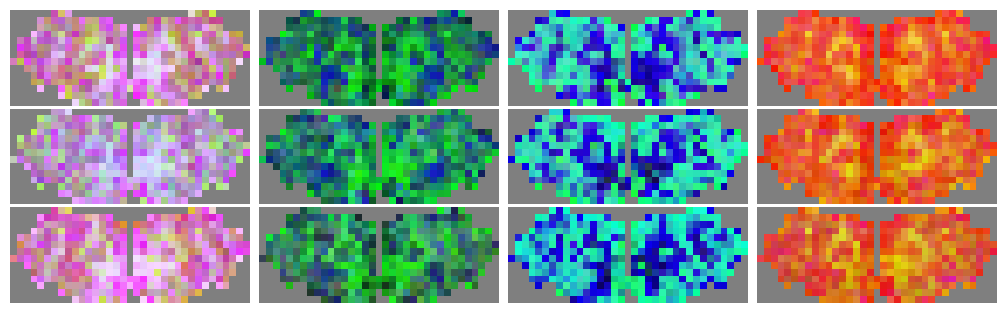

In [98]:
f = plot_rgb_component_maps(component_maps, num_subs=3)
f.savefig("pca_components.png", dpi=150)

In [96]:
def plot_images(
    images: np.ndarray,
    num_subs: int = 2,
):
    ploth = 1.0
    plotw = (W / H) * ploth

    nrow = num_subs
    ncol = len(include_targets)
    f, axs = plt.subplots(nrow, ncol, figsize=(ncol * plotw, nrow * ploth))

    for ii in range(nrow):
        for jj in range(ncol):
            ax = axs[ii, jj]
            plt.sca(ax)

            sub_id = ii
            sample_id = sub_id * ncol + jj
            print(include_ids.iloc[sample_id].to_dict())

            img = images[sample_id, 0, 5]
            img = np.where(img != 0, img, np.nan)
            plt.imshow(img, cmap=FC_CMAP, interpolation="none")

            plt.xticks([])
            plt.yticks([])
            ax.spines[:].set_visible(False)

    plt.tight_layout(pad=0.25)
    return f

{'sub': '100610', 'dir': 'RL', 'target': 0, 'index': 939}
{'sub': '100610', 'dir': 'RL', 'target': 3, 'index': 232}
{'sub': '100610', 'dir': 'RL', 'target': 11, 'index': 1523}
{'sub': '100610', 'dir': 'RL', 'target': 16, 'index': 495}
{'sub': '103818', 'dir': 'RL', 'target': 0, 'index': 2136}
{'sub': '103818', 'dir': 'RL', 'target': 3, 'index': 46}
{'sub': '103818', 'dir': 'RL', 'target': 11, 'index': 4892}
{'sub': '103818', 'dir': 'RL', 'target': 16, 'index': 2733}
{'sub': '105923', 'dir': 'RL', 'target': 0, 'index': 4928}
{'sub': '105923', 'dir': 'RL', 'target': 3, 'index': 2941}
{'sub': '105923', 'dir': 'RL', 'target': 11, 'index': 3794}
{'sub': '105923', 'dir': 'RL', 'target': 16, 'index': 832}


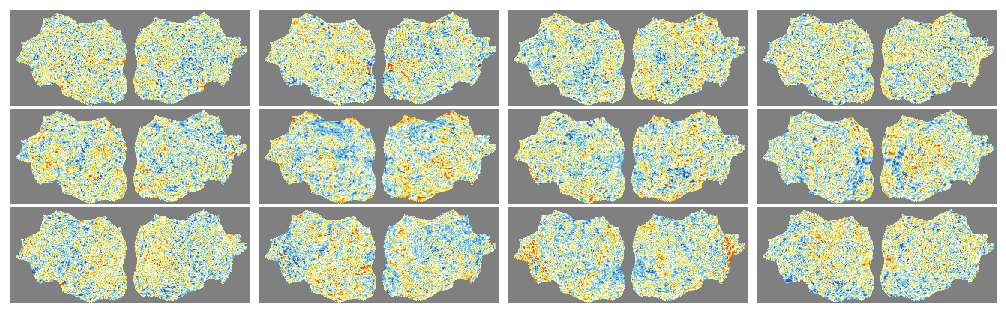

In [99]:
f = plot_images(images, num_subs=3)
f.savefig("pca_images.png", dpi=150)

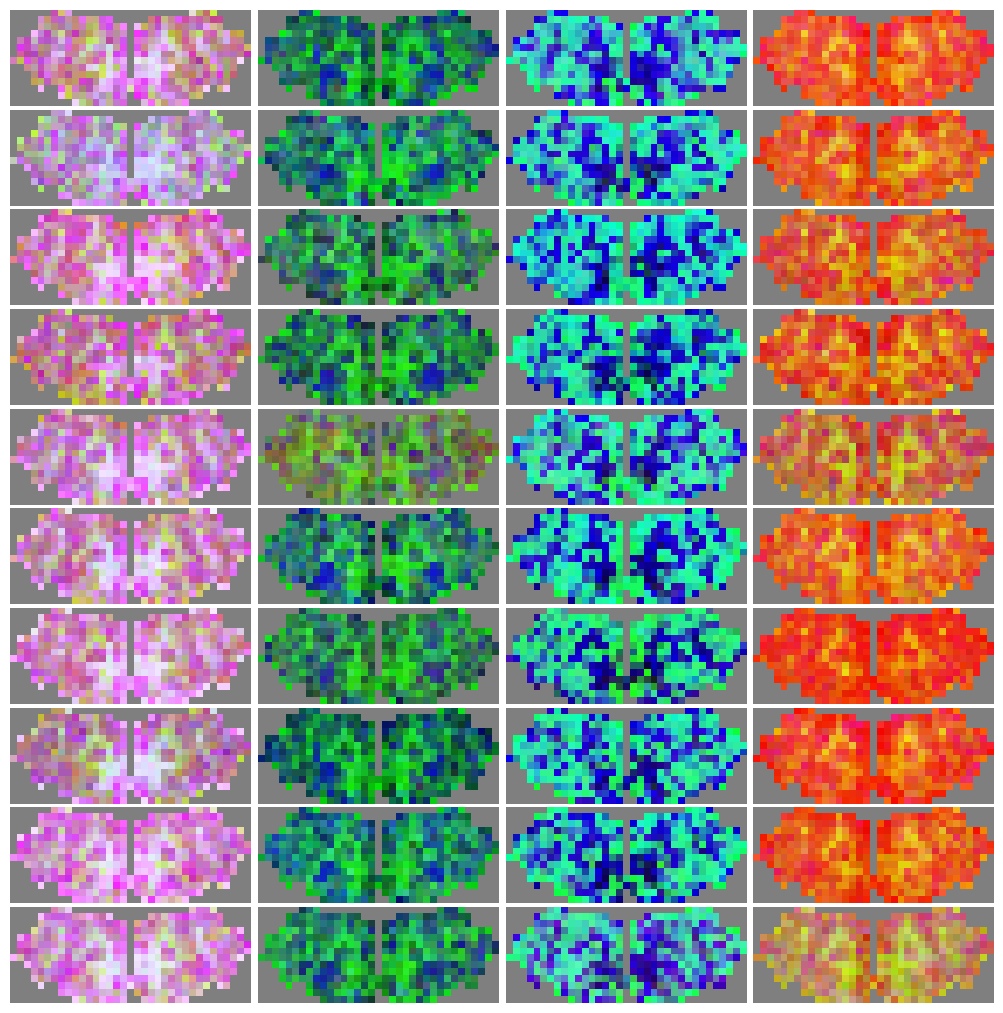

In [74]:
f = plot_rgb_component_maps(component_maps, ncol=4)

In [ ]:
def plot_image_rgb_component_maps(
    component_maps: np.ndarray,
    ncol: int = 12,
):
    ploth = 1.0
    plotw = (W / H) * ploth

    nrow = len(component_maps) // ncol
    f, axs = plt.subplots(nrow, ncol, figsize=(ncol * plotw, nrow * ploth))
    axs = axs.flatten()

    for ii, ax in enumerate(axs):
        plt.sca(ax)

        img = component_maps[ii, 0, :, :, :3]
        img = torch.sigmoid(2.0 * torch.from_numpy(img)).numpy()
        plt.imshow(img, interpolation="none")

        plt.xticks([])
        plt.yticks([])
        ax.spines[:].set_visible(False)

    plt.tight_layout(pad=0.25)
    return f